# Fourier reconstruction and causal filters
The FFT low band and SMA/EMA all isolate slower variation, but they are different operations. The FFT mask is an offline, sharp frequency cutoff on a periodic sample. SMA and EMA use only current and past inputs; their responses are smooth and introduce lag.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.data import download_prices, compute_log_returns

plt.rcParams.update({"axes.grid": True, "font.size": 10})
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

Use the same parameters as notebook 01. This notebook runs independently and reads the same cached prices.

In [2]:
TICKER = "SPY"
START = "2015-01-01"
END = "2026-10-03"
LOW_PERIOD = 60
HIGH_PERIOD = 10
DISPLAY_DAYS = 252
REFRESH = False

In [3]:
price_file = ROOT / "data" / f"{TICKER}_{START}_{END}.csv"
price_file.parent.mkdir(exist_ok=True)
if REFRESH or not price_file.exists():
    prices = download_prices(TICKER, START, END)
    prices.to_csv(price_file)
else:
    table = pd.read_csv(price_file, index_col="date", parse_dates=["date"])
    prices = table[TICKER]

returns = compute_log_returns(prices)
print(f"{TICKER}: {len(returns)} returns, {returns.index[0].date()} to {returns.index[-1].date()}")

SPY: 2954 returns, 2015-01-05 to 2026-10-02


`compute_spectrum` repeats the short FFT calculation from notebook 01 and returns its intermediate arrays. `make_frequency_masks` returns the three Boolean masks. The low coefficients and inverse transform stay explicit.

In [4]:
from src.fourier import compute_spectrum, make_frequency_masks
from src.filters import sma_filter, ema_filter, fir_frequency_response, ema_frequency_response

x, X, frequencies, periods, power = compute_spectrum(returns)
low_mask, mid_mask, high_mask = make_frequency_masks(periods, LOW_PERIOD, HIGH_PERIOD)
X_low = np.where(low_mask, X, 0)
x_low = np.fft.irfft(X_low, n=len(x))
mean_return = returns.mean()

## Match the cutoff
The Fourier boundary is $\omega_c=2\pi/60$. Match the causal filters' half-power gain, $|H(\omega_c)|=1/\sqrt{2}$ (approximately −3 dB), to that boundary.

For an M-point SMA, $h[n]=1/M$ for n=0,…,M−1. Search integer windows from 2 to twice the cutoff period. `np.argmin` finds the smallest gain error; `np.ones(M)/M` supplies the weights. The match is approximate because M is an integer.

In [5]:
omega_c = 2 * np.pi / LOW_PERIOD
target_gain = 1 / np.sqrt(2)
windows = np.arange(2, 2 * LOW_PERIOD + 1)
sma_gains = np.zeros(len(windows))
for i, window in enumerate(windows):
    weights = np.ones(window) / window
    sma_gains[i] = np.abs(fir_frequency_response(weights, omega_c))

best = np.argmin(np.abs(sma_gains - target_gain))
M = int(windows[best])
sma_weights = np.ones(M) / M
sma_filtered = sma_filter(returns, M)
assert np.isclose(sma_weights.sum(), 1)
print(f"SMA window: {M}; gain at cutoff: {sma_gains[best]:.6f}; target: {target_gain:.6f}")

SMA window: 27; gain at cutoff: 0.698966; target: 0.707107


## Matched EMA
$$s[t]=\alpha r[t]+(1-\alpha)s[t-1],\qquad
H(\omega)=\frac{\alpha}{1-(1-\alpha)e^{i\omega}}.$$
Setting $|H(\omega_c)|^2=1/2$ gives $\alpha^2+2q\alpha-2q=0$, where $q=1-\cos\omega_c$. Its positive root is $\alpha=\sqrt{q^2+2q}-q$.

Unrolling the recursion gives the infinite impulse response $h[n]=\alpha(1-\alpha)^n$. The code seeds the EMA at the first return. The equivalent span $2/\alpha-1$ is a parameter convention, not the cutoff period.

In [6]:
q = 1 - np.cos(omega_c)
alpha = np.sqrt(q**2 + 2*q) - q
ema_span = 2 / alpha - 1
ema_filtered = ema_filter(returns, alpha)
lags = np.arange(200)
ema_weights = alpha * (1 - alpha) ** lags
ema_cutoff_gain = np.abs(ema_frequency_response(omega_c, alpha))
assert 0 < alpha < 1
assert np.isclose(ema_cutoff_gain, target_gain)
assert np.isclose(ema_weights.sum(), 1 - (1 - alpha) ** len(lags))
assert np.isclose(ema_weights.sum(), 1, atol=1e-8)
print(f"EMA alpha: {alpha:.9f}; equivalent span: {ema_span:.4f}; cutoff gain: {ema_cutoff_gain:.6f}")

EMA alpha: 0.099337061; equivalent span: 19.1335; cutoff gain: 0.707107


Check one explicit SMA sum, one EMA recursive step, and causality. Changing observations after a cutoff must not change earlier filter outputs. `pd.testing.assert_series_equal` compares the values and their date index.

In [7]:
t = M + 5
explicit_sma = returns.iloc[t-M+1:t+1].sum() / M
explicit_ema = alpha * returns.iloc[t] + (1-alpha) * ema_filtered.iloc[t-1]
assert np.isclose(sma_filtered.iloc[t], explicit_sma)
assert np.isclose(ema_filtered.iloc[t], explicit_ema)

cutoff = len(returns) // 2
changed = returns.copy()
changed.iloc[cutoff+1:] = 0.5
pd.testing.assert_series_equal(sma_filter(changed, M).iloc[:cutoff+1], sma_filtered.iloc[:cutoff+1])
pd.testing.assert_series_equal(ema_filter(changed, alpha).iloc[:cutoff+1], ema_filtered.iloc[:cutoff+1])
print("Filter sums, recursion and causality checks passed.")

Filter sums, recursion and causality checks passed.


## Frequency responses
$$H_{SMA}(\omega)=\sum_{n=0}^{M-1}h[n]e^{i\omega n}.$$
The EMA response sums its geometric impulse response. `np.linspace` samples angular frequency in radians per trading day; `np.abs` gives response magnitude. Check both gains at DC and the finite EMA sum against its infinite-series formula. The figure zooms near the cutoff to show the SMA side lobes.

In [8]:
omega = np.linspace(0, np.pi, 2000)
H_sma = fir_frequency_response(sma_weights, omega)
H_ema = ema_frequency_response(omega, alpha)
H_ema_truncated = fir_frequency_response(ema_weights, omega)
assert np.isclose(H_sma[0], 1)
assert np.isclose(H_ema[0], 1)
assert np.allclose(H_ema_truncated, H_ema, atol=1e-8)
assert np.abs(sma_gains[best] - target_gain) < 0.02
print("Unit DC gains and frequency responses verified.")

Unit DC gains and frequency responses verified.


## Same cutoff, different filters
The top panel uses original returns for SMA/EMA and adds the sample mean back to `x_low` for the same DC level. The lower panel includes that restored DC in the ideal low-pass response.

The FFT mask cuts sharply at the boundary and uses the whole sample. The SMA rolls off with side lobes; the EMA rolls off monotonically. Both causal filters introduce phase delay, visible as lag relative to the offline component. Matching one cutoff does not match the full magnitude or phase responses, so the curves need not coincide.

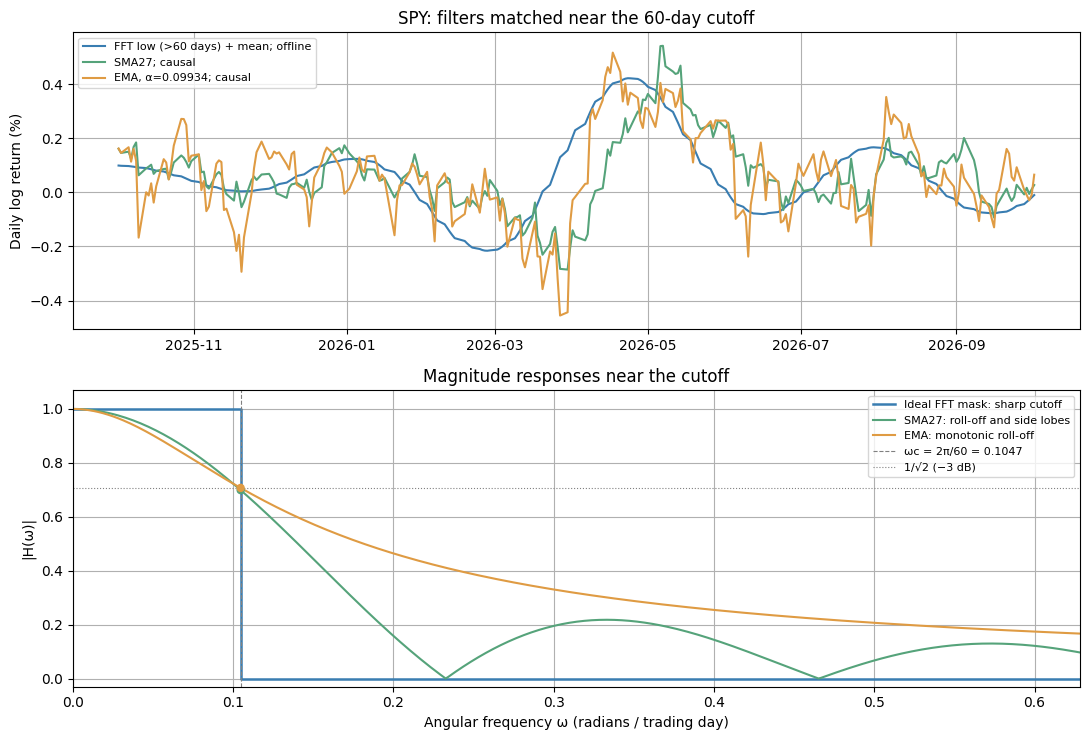

In [9]:
fft_low_with_mean = x_low + mean_return
view = slice(-DISPLAY_DAYS, None)
dates = returns.index
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5))
axes[0].plot(dates[view], fft_low_with_mean[view]*100, color="#397db1",
             label=f"FFT low (>{LOW_PERIOD} days) + mean; offline")
axes[0].plot(dates[view], sma_filtered.iloc[view]*100, color="#55a37a", label=f"SMA{M}; causal")
axes[0].plot(dates[view], ema_filtered.iloc[view]*100, color="#df9b43", label=f"EMA, α={alpha:.5f}; causal")
axes[0].set(title=f"{TICKER}: filters matched near the {LOW_PERIOD}-day cutoff", ylabel="Daily log return (%)")
axes[0].legend(fontsize=8, loc="upper left")

omega_end = min(np.pi, 6 * omega_c)
axes[1].step([0, omega_c, omega_end], [1, 0, 0], where="post",
             color="#397db1", linewidth=1.8, label="Ideal FFT mask: sharp cutoff")
axes[1].plot(omega, np.abs(H_sma), color="#55a37a", label=f"SMA{M}: roll-off and side lobes")
axes[1].plot(omega, np.abs(H_ema), color="#df9b43", label="EMA: monotonic roll-off")
axes[1].axvline(omega_c, color="grey", linestyle="--", linewidth=0.8,
                label=f"ωc = 2π/{LOW_PERIOD} = {omega_c:.4f}")
axes[1].axhline(target_gain, color="grey", linestyle=":", linewidth=0.8, label="1/√2 (−3 dB)")
axes[1].scatter([omega_c, omega_c], [sma_gains[best], ema_cutoff_gain],
                color=["#55a37a", "#df9b43"], s=25, zorder=5)
axes[1].set(xlim=(0, omega_end), ylim=(-0.03, 1.07), title="Magnitude responses near the cutoff",
            xlabel="Angular frequency ω (radians / trading day)", ylabel="|H(ω)|")
axes[1].legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES / "04_filter_comparison.png", dpi=150)
plt.show()